<a href="https://colab.research.google.com/github/Rafael-Labarrere/Djikstra-vs-A_Star-/blob/main/Djikstra_vs_A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install matplotlib osmnx --quiet

In [ ]:
pip install networkx

In [ ]:
import osmnx as ox
import networkx as nx

# --- 1. Preparação do Grafo e Definições ---

# Região de estudo
G = ox.graph_from_place("Plano Piloto, Brasília, Brazil", network_type='drive')

# Definição dos pontos (lat, lon)
origem = (-15.794003232345588, -47.88742220334444)   # ponto A
destino = (-15.801541242572645, -47.88310972634947)  # ponto B

In [ ]:
# Encontrar os nós mais próximos no grafo
orig_node = ox.distance.nearest_nodes(G, X=origem[1], Y=origem[0])
dest_node = ox.distance.nearest_nodes(G, X=destino[1], Y=destino[0])
print(f"🔹 Nó de origem: {orig_node}")
print(f"🔹 Nó de destino: {dest_node}")

# Define velocidades médias padrão (km/h) por tipo de via
# Usado para calcular Tempo e Emissões
VELOCIDADES = {
    "motorway": 100, "trunk": 80, "primary": 60,
    "secondary": 50, "tertiary": 40, "residential": 30
}
# Parâmetros de Custo (Exemplo de carro a gasolina)
PRECO_COMBUSTIVEL = 6.50  # R$ / litro
CONSUMO_KM_L = 12.5       # km / litro
EMISSAO_CO2_G_L = 2300    # Gramas de CO2 por litro de gasolina queimado

# --- 2. Adicionar Atributos de Custo ao Grafo ---

for u, v, k, data in G.edges(keys=True, data=True):
    # 1. Preparação dos dados
    tipo = data.get("highway", "residential")
    if isinstance(tipo, list): tipo = tipo[0]
    vel = VELOCIDADES.get(tipo, 30)  # Velocidade (km/h)
    dist_m = data["length"]          # Distância (metros)
    dist_km = dist_m / 1000          # Distância (km)

    # 2. Cálculo do Custo 1: TEMPO (em horas)
    tempo_h = dist_km / vel
    data["time_cost"] = tempo_h

    # 3. Cálculo do Custo 2: CUSTO FINANCEIRO PONDERADO
    consumo_litros = dist_km / CONSUMO_KM_L
    custo_combustivel = consumo_litros * PRECO_COMBUSTIVEL
    # Ponderação: Custo Combustível + Penalidade por Tempo (R$10/hora)
    data["financial_cost"] = custo_combustivel + (tempo_h * 10)

    # 4. Cálculo do Custo 3: CUSTO DE CARBONO (em kg de CO₂)
    emissao_g = consumo_litros * EMISSAO_CO2_G_L
    emissao_kg = emissao_g / 1000
    data["carbon_cost"] = emissao_kg

# --- 3. Calcular Rotas para os Três Critérios ---

# Critério 1: Distância Física Mínima
rota_distancia = nx.shortest_path(G, orig_node, dest_node, weight="length")

# Critério 2: Custo Financeiro Mínimo (Combustível + Tempo Penalizado)
rota_financeira = nx.shortest_path(G, orig_node, dest_node, weight="financial_cost")

# Critério 3: Custo de Carbono Mínimo (Emissões de CO₂ Mínimas)
rota_carbono = nx.shortest_path(G, orig_node, dest_node, weight="carbon_cost")

# --- 4. Apresentar os Resultados e a Análise Multiobjetivo ---

criterios = ["length", "financial_cost", "carbon_cost"]
rotas = {
    "Rota Mais Curta": rota_distancia,
    "Rota Financeira": rota_financeira,
    "Rota de Baixo Carbono": rota_carbono
}

print("\n--- 📊 Análise Comparativa das Rotas ---")
print("CUSTO: Rota ideal para minimizar o critério de CUSTO.")
print("OBJETIVOS: Custo dessa rota nos demais critérios.")

# Tabela de Resultados
data_table = []
for nome, rota in rotas.items():
    # Calcula a Distância Total (length)
    dist_m = nx.path_weight(G, rota, weight="length")
    # Calcula o Custo Financeiro Total (financial_cost)
    custo_financeiro = nx.path_weight(G, rota, weight="financial_cost")
    # Calcula o Custo de Carbono Total (carbon_cost)
    custo_carbono = nx.path_weight(G, rota, weight="carbon_cost")

    data_table.append([
        nome,
        f"{dist_m/1000:.2f} km",
        f"R$ {custo_financeiro:.2f}",
        f"{custo_carbono:.2f} kg"
    ])

# Exibe a Tabela
print(f"| {'CRITÉRIO OTIMIZADO':<25} | {'DISTÂNCIA':<12} | {'CUSTO FINANCEIRO':<17} | {'CARBONO (CO₂)':<15} |")
print("|" + "-" * 26 + "|" + "-" * 13 + "|" + "-" * 18 + "|" + "-" * 16 + "|")
for row in data_table:
    print(f"| {row[0]:<25} | {row[1]:<12} | {row[2]:<17} | {row[3]:<15} |")



🔹 Nó de origem: 984930889
🔹 Nó de destino: 2187538593

--- 📊 Análise Comparativa das Rotas ---
CUSTO: Rota ideal para minimizar o critério de CUSTO.
OBJETIVOS: Custo dessa rota nos demais critérios.
| CRITÉRIO OTIMIZADO        | DISTÂNCIA    | CUSTO FINANCEIRO  | CARBONO (CO₂)   |
|--------------------------|-------------|------------------|----------------|
| Rota Mais Curta           | 1.44 km      | R$ 1.05           | 0.26 kg         |
| Rota Financeira           | 1.44 km      | R$ 1.05           | 0.26 kg         |
| Rota de Baixo Carbono     | 1.44 km      | R$ 1.05           | 0.26 kg         |


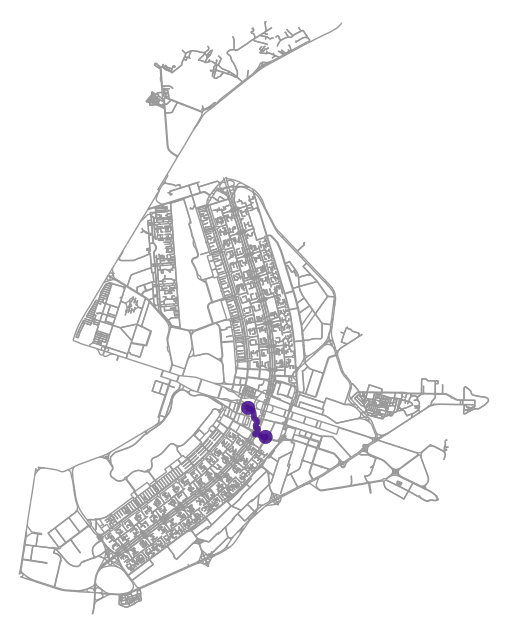


🖼️ Gráfico salvo como rotas_multiobjetivo.png (Rota Curta=Verde, Financeira=Vermelha, Carbono=Azul).


In [ ]:
# --- 5. Visualização ---
ox.plot_graph_routes(
    G,
    [rota_distancia, rota_financeira, rota_carbono],
    route_colors=['green', 'red', 'blue'],
    route_linewidth=4,
    node_size=0,
    bgcolor='white',
    save=True,
    filepath='rotas_multiobjetivo.png',
    dpi=300
)
print("\n🖼️ Gráfico salvo como rotas_multiobjetivo.png (Rota Curta=Verde, Financeira=Vermelha, Carbono=Azul).")

In [ ]:
# Exibir todos os nós e pesos da rota
print("\n🗺️ Vértices visitados na rota:")
for i in range(len(rota) - 1):
    u = rota[i]
    v = rota[i + 1]
    dados = G.get_edge_data(u, v, 0)
    print(f"{i+1}. {u} → {v} | Distância: {dados['length']:.1f} m | Tipo: {dados.get('highway', 'desconhecido')}")


🗺️ Vértices visitados na rota:
1. 984930889 → 2525505066 | Distância: 157.5 m | Tipo: secondary
2. 2525505066 → 370527968 | Distância: 40.8 m | Tipo: secondary
3. 370527968 → 142201583 | Distância: 362.6 m | Tipo: secondary
4. 142201583 → 6544727624 | Distância: 51.4 m | Tipo: primary
5. 6544727624 → 6544727666 | Distância: 47.4 m | Tipo: primary
6. 6544727666 → 6544727672 | Distância: 82.1 m | Tipo: primary_link
7. 6544727672 → 6544727665 | Distância: 47.4 m | Tipo: primary
8. 6544727665 → 6544727655 | Distância: 85.6 m | Tipo: primary
9. 6544727655 → 8341033829 | Distância: 39.8 m | Tipo: primary
10. 8341033829 → 8334004766 | Distância: 80.8 m | Tipo: primary
11. 8334004766 → 142282217 | Distância: 51.2 m | Tipo: primary_link
12. 142282217 → 142282225 | Distância: 48.7 m | Tipo: trunk_link
13. 142282225 → 142282019 | Distância: 151.1 m | Tipo: secondary
14. 142282019 → 2187538601 | Distância: 154.2 m | Tipo: secondary
15. 2187538601 → 2187538593 | Distância: 38.0 m | Tipo: secondary

In [ ]:
import heapq
import networkx as nx
import osmnx as ox

# =========================================================
# Dijkstra instrumentado: registra todas as relaxações
# =========================================================
def dijkstra_instrumentado(G, source, target, weight='length'):

    visited = set()                                  # nós já extraídos da fila
    dist = {node: float('inf') for node in G.nodes()} # distância acumulada
    parent = {node: None for node in G.nodes()}       # pai na árvore de caminho
    relaxacoes = []                                   # armazena toda relaxação
    fila = [(0, source)]                              # min-heap de prioridades

    dist[source] = 0

    while fila:
        d, u = heapq.heappop(fila)

        if u in visited:
            continue
        visited.add(u)

        if u == target:
            break

        # Sucessores para digrafo ou vizinhos para grafo não direcionado
        vizinhos = G.successors(u) if G.is_directed() else G.neighbors(u)

        for v in vizinhos:

            # Pegar peso (trata MultiDiGraph)
            try:
                # caso seja um multigrafo, pegar qualquer key (0)
                w = list(G[u][v].values())[0].get(weight, 1)
            except:
                # grafo simples
                w = G[u][v].get(weight, 1)

            # relaxação
            if dist[u] + w < dist[v]:
                antiga = dist[v]
                nova = dist[u] + w

                dist[v] = nova
                parent[v] = u
                heapq.heappush(fila, (nova, v))

                relaxacoes.append({
                    "origem": u,
                    "destino": v,
                    "dist_antiga": antiga,
                    "dist_nova": nova
                })

    # Reconstrução do caminho final
    caminho_final = []
    no = target
    while no is not None:
        caminho_final.append(no)
        no = parent[no]
    caminho_final = caminho_final[::-1]

    return dist[target], caminho_final, relaxacoes



# =========================================================
#      EXEMPLO DE USO (EDITAR ORIGEM E DESTINO)
# =========================================================

# Carregar o grafo (use a mesma área da sua rota)
G = ox.graph_from_place("Plano Piloto, Brasília, Brazil", network_type="drive")

# Definir origem e destino (SUBSTITUA pelos seus nós!)
source = 984930889
target = 2187538593

# Rodar o Dijkstra instrumentado
dist_final, caminho_final, relaxacoes = dijkstra_instrumentado(G, source, target)

print("\n==============================================")
print("MENOR CAMINHO ENCONTRADO:")
print(caminho_final)
print("Distância total =", dist_final)
print("==============================================\n")

# =========================================================
# Rotas descartadas (relaxações fora do caminho ótimo)
# =========================================================
rotas_descartadas = [
    r for r in relaxacoes
    if not (r["origem"] in caminho_final and r["destino"] in caminho_final)
]

print("ROTAS VERIFICADAS E DESCARTADAS PELO DIJKSTRA:")
print("(todas as relaxações que NÃO fazem parte do caminho final)\n")

for r in rotas_descartadas:
    print(
        f"{r['origem']} → {r['destino']} | "
        f"dist antiga={r['dist_antiga']:.2f} | "
        f"dist nova={r['dist_nova']:.2f}"
    )

print("\n==============================================")
print(f"Total de relaxações realizadas: {len(relaxacoes)}")
print(f"Total de rotas descartadas: {len(rotas_descartadas)}")
print("==============================================\n")



MENOR CAMINHO ENCONTRADO:
[984930889, 2525505066, 370527968, 142201583, 6544727624, 6544727666, 6544727672, 6544727665, 6544727655, 8341033829, 8334004766, 142282217, 142282225, 142282019, 2187538601, 2187538593]
Distância total = 1438.7852099896597

ROTAS VERIFICADAS E DESCARTADAS PELO DIJKSTRA:
(todas as relaxações que NÃO fazem parte do caminho final)

984930889 → 7238344044 | dist antiga=inf | dist nova=239.03
2525505066 → 1387142316 | dist antiga=inf | dist nova=186.23
1387142316 → 1387142318 | dist antiga=inf | dist nova=284.80
7238344044 → 7238344046 | dist antiga=inf | dist nova=246.69
7238344044 → 984930903 | dist antiga=inf | dist nova=385.38
7238344046 → 6150614685 | dist antiga=inf | dist nova=268.94
7238344046 → 8512049000 | dist antiga=inf | dist nova=314.04
6150614685 → 4183781294 | dist antiga=inf | dist nova=521.20
1387142318 → 7244216113 | dist antiga=inf | dist nova=395.15
8512049000 → 8512049001 | dist antiga=inf | dist nova=350.47
8512049001 → 8512049002 | dist an

Caminho final:
[984930889, 2525505066, 370527968, 142201583, 6544727624, 6544727666, 6544727672, 6544727665, 6544727655, 8341033829, 8334004766, 142282217, 142282225, 142282019, 2187538601, 2187538593]


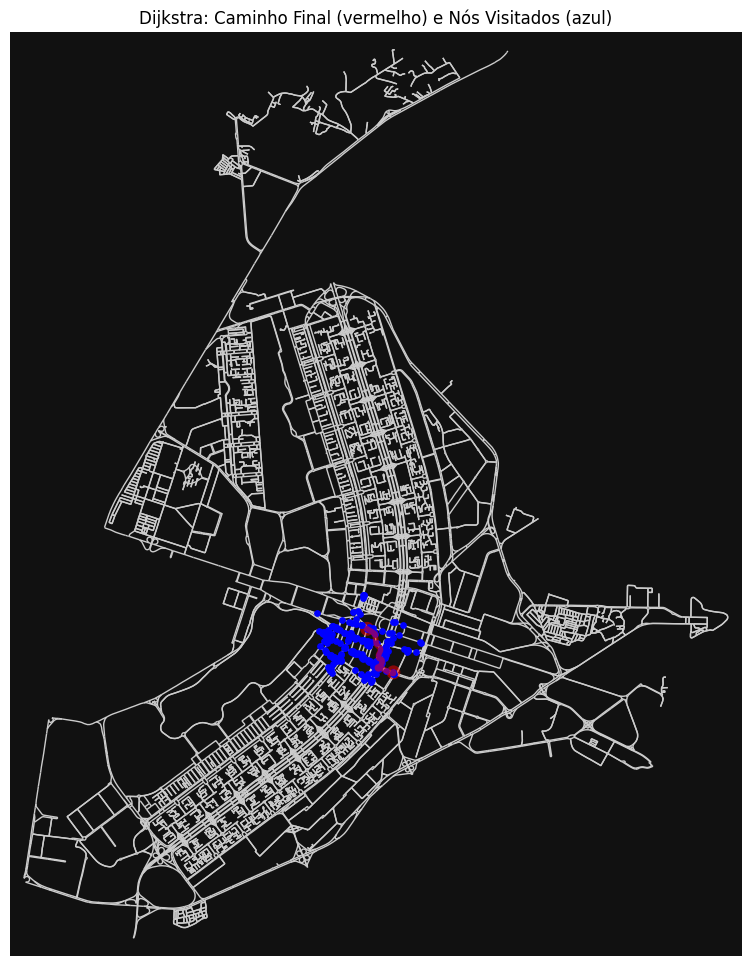

In [ ]:
import heapq
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

# =========================================================
# Dijkstra instrumentado: registra todas as relaxações
# =========================================================
def dijkstra_instrumentado(G, source, target, weight='length'):

    visited = set()
    dist = {node: float('inf') for node in G.nodes()}
    parent = {node: None for node in G.nodes()}
    relaxacoes = []
    fila = [(0, source)]

    dist[source] = 0

    while fila:
        d, u = heapq.heappop(fila)

        if u in visited:
            continue
        visited.add(u)

        if u == target:
            break

        vizinhos = G.successors(u) if G.is_directed() else G.neighbors(u)

        for v in vizinhos:
            try:
                w = list(G[u][v].values())[0].get(weight, 1)
            except:
                w = G[u][v].get(weight, 1)

            if dist[u] + w < dist[v]:
                antiga = dist[v]
                nova = dist[u] + w

                dist[v] = nova
                parent[v] = u
                heapq.heappush(fila, (nova, v))

                relaxacoes.append((u, v))

    # Reconstruir caminho final
    caminho_final = []
    no = target
    while no is not None:
        caminho_final.append(no)
        no = parent[no]
    caminho_final = caminho_final[::-1]

    return visited, caminho_final, relaxacoes


# =========================================================
# CONFIGURAR A ROTA (ALTERE SE PRECISAR)
# =========================================================

G = ox.graph_from_place("Plano Piloto, Brasília, Brazil", network_type="drive")

source = 984930889
target = 2187538593

visited, caminho_final, relaxacoes = dijkstra_instrumentado(G, source, target)

print("Caminho final:")
print(caminho_final)


# ---------------------------------------------------------
# SEPARAR ARESTAS DO CAMINHO FINAL
# ---------------------------------------------------------
arestas_caminho = set()
for u, v in zip(caminho_final[:-1], caminho_final[1:]):
    if G.has_edge(u, v):
        arestas_caminho.add((u, v))


# =========================================================
#           VISUALIZAÇÃO NO MAPA OSMNX
# =========================================================

# Plot base
fig, ax = ox.plot_graph(G, node_size=0, edge_color="#cccccc",
                        show=False, close=False, figsize=(12, 12))

# 🔴 CAMINHO FINAL
ox.plot_graph_route(
    G,
    caminho_final,
    route_color="red",
    route_linewidth=4,
    ax=ax,
    show=False,
    close=False
)

# 🔵 NÓS VISITADOS
xs = [G.nodes[n]["x"] for n in visited]
ys = [G.nodes[n]["y"] for n in visited]
ax.scatter(xs, ys, c="blue", s=15, label="Nós visitados")

plt.title("Dijkstra: Caminho Final (vermelho) e Nós Visitados (azul)")
plt.show()


Nós visitados: 42
Relaxações: 57
Tamanho do caminho: 16 nós


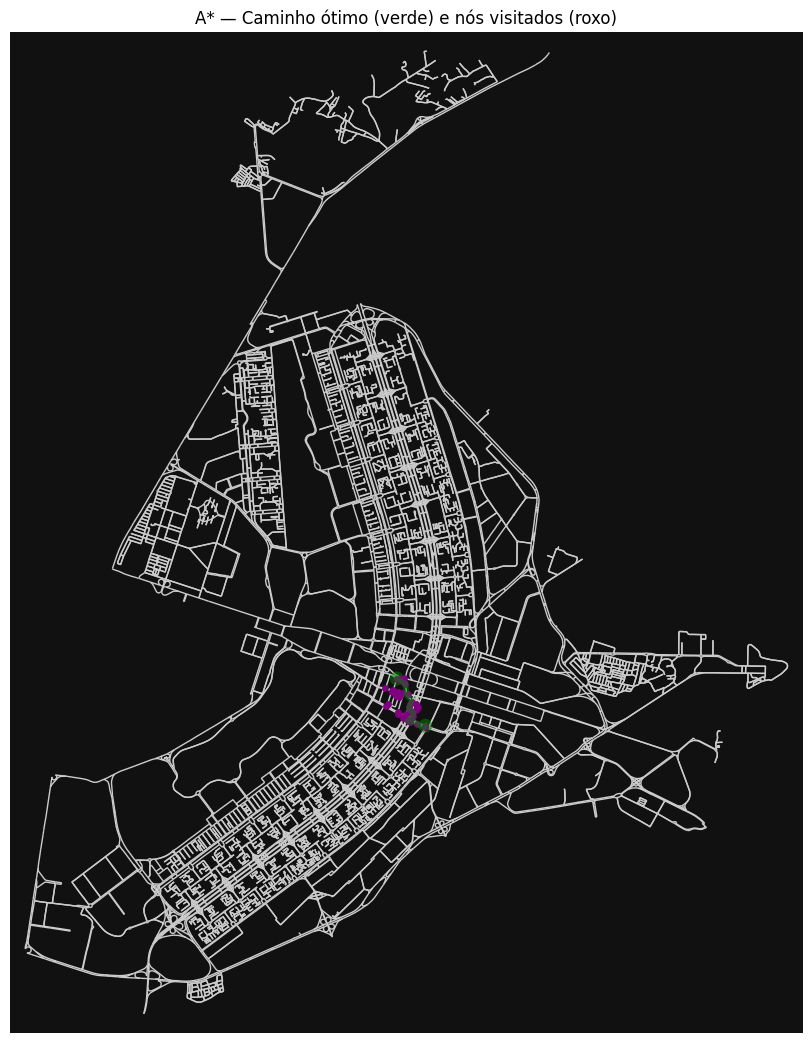

In [ ]:
import heapq
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

# =========================================================
# Função Haversine (heurística do A*)
# =========================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371e3  # raio da Terra (m)
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = phi2 - phi1
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1) * cos(phi2) * sin(dlambda/2)**2
    return R * (2 * atan2(sqrt(a), sqrt(1 - a)))


# =========================================================
# A* INSTRUMENTADO
# =========================================================
def astar_instrumentado(G, source, target, weight='length'):

    visited = set()
    dist = {n: float('inf') for n in G.nodes()}
    parent = {n: None for n in G.nodes()}
    relaxacoes = []

    # Coordenadas do destino
    lat_t = G.nodes[target]['y']
    lon_t = G.nodes[target]['x']

    pq = []
    dist[source] = 0

    heapq.heappush(pq, (0, source))  # F = G + H

    while pq:
        f, u = heapq.heappop(pq)

        if u in visited:
            continue
        visited.add(u)

        if u == target:
            break

        neighbors = G.successors(u) if G.is_directed() else G.neighbors(u)

        for v in neighbors:
            w = list(G[u][v].values())[0].get(weight, 1)

            # Heurística (distância em linha reta ao destino)
            h = haversine(G.nodes[v]['y'], G.nodes[v]['x'], lat_t, lon_t)

            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u
                relaxacoes.append((u, v))
                heapq.heappush(pq, (dist[v] + h, v))

    # Caminho final
    cam = []
    no = target
    while no is not None:
        cam.append(no)
        no = parent[no]
    cam.reverse()

    return visited, cam, relaxacoes


# =========================================================
# EXECUTAR NO GRAFO REAL
# =========================================================
G = ox.graph_from_place("Plano Piloto, Brasília, Brazil", network_type='drive')

source = 984930889
target = 2187538593

visited, caminho, relaxacoes = astar_instrumentado(G, source, target)

print("Nós visitados:", len(visited))
print("Relaxações:", len(relaxacoes))
print("Tamanho do caminho:", len(caminho), "nós")


# =========================================================
# VISUALIZAÇÃO — SOMENTE A*
# =========================================================
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="#cccccc",
    show=False,
    close=False,
    figsize=(13, 13)
)

# 🟢 Caminho final A*
ox.plot_graph_route(
    G,
    caminho,
    route_color="green",
    route_linewidth=4,
    ax=ax,
    show=False,
    close=False
)

# 🟣 Nós visitados pelo A*
xs = [G.nodes[n]["x"] for n in visited]
ys = [G.nodes[n]["y"] for n in visited]
ax.scatter(xs, ys, c="purple", s=15, label="Nós visitados A*")

plt.title("A* — Caminho ótimo (verde) e nós visitados (roxo)")
plt.show()

In [ ]:
import heapq
import osmnx as ox
import networkx as nx
from math import radians, sin, cos, sqrt, atan2


# ===========================
# Função de distância haversine (em metros)
# ===========================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))


# ===========================
# A* modificado para registrar relaxações
# ===========================
def astar_track(G, source, target):
    # Coordenadas do destino
    lat_t = G.nodes[target]["y"]
    lon_t = G.nodes[target]["x"]

    # Heurística para cada nó
    def h(n):
        lat = G.nodes[n]['y']
        lon = G.nodes[n]['x']
        return haversine(lat, lon, lat_t, lon_t)

    # Distâncias
    dist = {n: float('inf') for n in G.nodes()}
    dist[source] = 0

    # Onde veio cada nó
    parent = {}

    # Heap
    pq = [(h(source), source)]

    relaxations = []   # Todas as relaxações feitas
    visited = set()    # Nós realmente expandidos pelo A*

    while pq:
        f, u = heapq.heappop(pq)

        if u in visited:
            continue
        visited.add(u)

        if u == target:
            break

        for v in G.successors(u):
            w = G[u][v][0]["length"]

            old = dist[v]
            new = dist[u] + w

            if new < old:
                dist[v] = new
                parent[v] = u
                heapq.heappush(pq, (new + h(v), v))

                relaxations.append((u, v, old, new))

    # Reconstruir caminho
    path = []
    cur = target
    while cur in parent:
        path.append(cur)
        cur = parent[cur]
    path.append(source)
    path = path[::-1]

    return path, dist[target], relaxations, visited


# ===========================
# EXECUTAR A*
# ===========================
source = 984930889
target = 2187538593

path, dist_final, relaxations, visited_nodes = astar_track(G, source, target)

# ===========================
# EXIBIR RESULTADOS
# ===========================
print("==============================================")
print("MENOR CAMINHO ENCONTRADO (A*):")
print(path)
print("Distância total =", dist_final)
print("==============================================\n")

print("ROTAS VERIFICADAS E DESCARTADAS PELO A*:")
print("(todas as relaxações que NÃO fazem parte do caminho final)\n")

# Transformar o caminho em conjunto de pares para fácil verificação
edge_set = set(zip(path[:-1], path[1:]))

descartadas = 0

for u, v, old, new in relaxations:
    if (u, v) not in edge_set:
        descartadas += 1
        print(f"{u} → {v} | dist antiga={old} | dist nova={new}")

print("\n==============================================")
print("Total de relaxações realizadas:", len(relaxations))
print("Total de rotas descartadas:", descartadas)
print("==============================================")


MENOR CAMINHO ENCONTRADO (A*):
[984930889, 2525505066, 370527968, 142201583, 6544727624, 6544727666, 6544727672, 6544727665, 6544727655, 8341033829, 8334004766, 142282217, 142282225, 142282019, 2187538601, 2187538593]
Distância total = 1438.7852099896597

ROTAS VERIFICADAS E DESCARTADAS PELO A*:
(todas as relaxações que NÃO fazem parte do caminho final)

984930889 → 7238344044 | dist antiga=inf | dist nova=239.02757961589958
2525505066 → 1387142316 | dist antiga=inf | dist nova=186.23110892269565
1387142316 → 1387142318 | dist antiga=inf | dist nova=284.80470590811495
6544727666 → 142282814 | dist antiga=inf | dist nova=814.6905169572472
7238344044 → 7238344046 | dist antiga=inf | dist nova=246.69396280034064
7238344044 → 984930903 | dist antiga=inf | dist nova=385.37793036940036
6544727665 → 142281364 | dist antiga=inf | dist nova=877.7765992265099
7238344046 → 6150614685 | dist antiga=inf | dist nova=268.9444446043417
7238344046 → 8512049000 | dist antiga=inf | dist nova=314.03993501

IGNORAR CÓDIGO ABAIXO!

In [ ]:
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}
# --- 2. PLOTAGEM DO GRAFO BASE COMPLETO ---
fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')
ax.set_facecolor('white')

plt.title("Grafo de Ruas Completo: Plano Piloto, Brasília", fontsize=16)
# Plotar todas as arestas em cinza claro (Rede de Ruas)
nx.draw_networkx_edges(
    G,
    pos,
    edge_color='#cccccc', # Cinza muito claro
    width=0.5,
    ax=ax,
    alpha=0.8
)
# Plotar todos os nós (Vértices) em azul pequeno
nx.draw_networkx_nodes(
    G,
    pos,
    node_color='darkblue',
    node_size=5, # Tamanho bem pequeno para não poluir
    ax=ax,
    alpha=0.7,
)
plt.axis('off')
plt.savefig('grafo_base_plano_piloto.png', facecolor='white', bbox_inches='tight')
plt.close(fig)
print("\n🖼️ Grafo Base do Plano Piloto salvo como grafo_base_plano_piloto.png.")


🖼️ Grafo Base do Plano Piloto salvo como grafo_base_plano_piloto.png.
